In [2]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


In [ ]:
my_image_path = 'aiffel/camera_sticker/images/image.png' # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

- opencv는 예외적으로 BGR(파랑, 녹색, 빨강)을 사용
- 원본 사진에서 붉은색은 푸른색으로, 푸른색은 붉은색으로 바뀌어 출력
- opencv에서 다룬 이미지를 다른 이미지 라이브러리를 활용하여 출력하려면 아래와 같은 색깔 보정처리가 필요

In [ ]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

### OpenCV
- [OpenCV python image start](https://opencv-python.readthedocs.io/en/latest/doc/01.imageStart/imageStart.html)
- `cv2.imread(fileName, flag)`
  - cv2.IMREAD_COLOR    (-1) : Color, 투명한 부분은 무시, Default
  - cv2.IMREAD_GRAYSCALE (0) : Grayscale, 실제 이미지 처리시 중간단계로 많이 사용
  - cv2.IMREAD_UNCHANGED (1) : alpha channel까지 포함

### Face detection
- `dlib` face detector : HOG(Histogram of Oriented Gradients)와 SVM(Support Vector Machine)을 사용
- HOG를 통해 이미지를 벡터로 만들어 SVM으로 분류
- Sliding window를 이용하여 얼굴이 있는지 확인

#### [**HOG (Histogram of Oriented Gradients)**](https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_hog.html)  
![hog](https://scikit-image.org/docs/dev/_images/sphx_glr_plot_hog_001.png)

#### **SVM**
- 선형 분류기


In [ ]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

dlib은 rgb 이미지를 입력으로 받기 때문에 cvtColor() 를 이용해서 opencv 의 bgr 이미지를 rgb로 변환

In [1]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

NameError: name 'cv2' is not defined

- detector_hog의 두 번째 파라미터는 이미지 피라미드의 수
- [이미지 피라미드](https://opencv-python.readthedocs.io/en/latest/doc/14.imagePyramid/imagePyramid.html) : 이미지를 upsampling 방법을 통해 크기를 키우는 것
- upsampling : 데이터의 크기를 키우는 것

In [ ]:
### 찾은 얼굴을 화면에 출력
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

[dlib docs](http://dlib.net/python/index.html#dlib.rectangles)
- dlib detector 는 dlib.rectangles 타입의 객체를 반환
- dlib.rectangles 는 dlib.rectangle 객체의 배열 형태로 이루어져 있음
- dlib.rectangle객체는 left(), top(), right(), bottom(), height(), width() 등의 멤버 함수를 포함

- rectangles[[(345, 98) (531, 284)]]
  - left, top, right, bottom의 좌표 : 345, 98, 531, 284

#### face landmark localization
- 이목구비 위치를 추론
- detection의 결과물인 bounding box로 잘라낸(crop) 얼굴 이미지를 이용
- Object keypoint estimation 알고리즘
  - 객체 내부의 점을 찾는 기술
  - top-down : bounding box를 찾고 box 내부의 keypoint를 예측
  - bottom-up : 이미지 전체의 keypoint를 먼저 찾고 point 관계를 이용해 군집화 해서 box 생성

**Dlib landmark localization**  
- 점의 개수는 데이터셋과 논문마다 다름
- ibug [300-W 데이터셋](https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/)으로 학습한 pretrained model 을 제공
- 학습 알고리즘은 [regression tree의 앙상블 모델](https://www.researchgate.net/publication/264419855_One_Millisecond_Face_Alignment_with_an_Ensemble_of_Regression_Trees)을 사용

In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/aiffel/camera_sticker/models
!cd ~/aiffel/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

저장한 모델 불러오기

In [ ]:
model_path = 'aiffel/camera_sticker/models/shape_predictor_68_face_landmarks.dat'
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

**랜드마크 찾기**  
- `points`는 `dlib.full_object_detection`의 객체이기 때문에 `parts()` 함수로 개별 위치에 접근 가능
- (x, y) 형태로 접근할 수 있도록 변환


In [ ]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_rgb, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 랜드마크 리스트를 저장
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

랜드마크와 함께 이미지 출력

In [ ]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

#### 스티커 붙이기
- 얼굴 위치, 카메라의 거리에 따라 픽셀 `x` 가 다르기 때문에 비율로 계산해줘야 함
- 이미지는 좌상단이 (0,0), 내려올수록 y가 커짐


코 찾기

In [ ]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(345, 98) (531, 284)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2 # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

스티커 불러오기

In [ ]:
sticker_path = os.getenv('HOME')+'/aiffel/camera_sticker/images/king.png' # 왕관 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 왕관 이미지의 차원 확인

스티커 위치 계산하기
- 스티커의 시작점이 얼굴 사진의 영역을 벗어나면 음수로 표현
- opencv 데이터는 numpy ndarray 형태의 데이터를 사용
- ndarray는 음수 인덱스에 접근할 수 없기 때문에 **음수에 대한 예외 처리**를 해줘야 함
- 스티커의 시작점 + 스티커 사진의 크기가 **원본 이미지의 크기보다 큰 경우**도 예외 처리 해줘야 함

In [ ]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 437
# y는 이미지에서 코 부위의 y값 = 89
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
refined_x = x - w // 2 # 437 - (187//2) = 437-93 = 344
refined_y = y - h # 89-187 = -98
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.
# 즉, refined_x, refined_y값에서 왕관 이미지가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') # 음수 발생 : 이미지 범위를 벗어남
# 우리는 현재 이마 자리에 왕관을 두고 싶은건데, 이마위치 - 왕관 높이를 했더니 이미지의 범위를 초과하여 음수가 나오는 것
# opencv는 ndarray데이터를 사용하는데, ndarray는 음수인덱스에 접근 불가하므로 스티커 이미지를 잘라 줘야 한다.

스티커 잘라주기

In [ ]:
# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지 입니다.
# 예제에서는 (344,0) 부터 (344+187, 0+89) 범위의 이미지를 의미합니다.
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_show[0:0+89, 344:344+187]
# img_show[0:89, 344:531]
# 즉, x좌표는 344~531 / y좌표는 0~89가 됨
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 왕관 이미지에서 사용할 부분은 0이 아닌 색이 있는 부분을 사용합니다.
# 왕관 이미지에서 0이 나오는 부분은 흰색이라는 뜻, 즉 이미지가 없다는 소리임.
# 현재 왕관 이미지에서는 왕관과 받침대 밑의 ------ 부분이 됨
# 그렇기 때문에 0인 부분(이미지가 없는 부분)은 제외하고 적용
# sticker_area는 원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지입니다.
# 즉, 왕관 이미지에서 왕관 이미지가 없는 부분(왕관과 받침대 밑의 ------ 부분)은 원본 이미지에서 미리 잘라놓은 sticker_area(스티커 적용할 부분 만큼 원본 이미지에서 자른 이미지)를 적용하고,
# 나머지 부분은 스티커로 채워주면 됨
# np.where는 조건에 해당하는 인덱스만 찾아서 값을 적용하는 방법이다.
# 아래 코드에서는 img_sticker가 0일 경우(왕관 이미지에서 왕관 부분 제외한 나머지 이미지)에는 sticker_area(원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지)를 적용하고,
# 나머지 부분은 img_sticker(왕관 이미지)를 적용한다.
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
print("슝~")

스티커 붙인 사진 그리기

In [ ]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

랜드마크 없는 사진 활용

In [ ]:
# 위에서 설명했으므로 생략
# 왕관 이미지
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_bgr은 7-2에서 rgb로만 적용해놓은 원본 이미지이다.
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) # rgb만 적용해놓은 원본 이미지에 왕관 이미지를 덮어 씌운 이미지가 나오게 된다.
plt.show()

## Exploration 03
고양이 수염 붙이기

In [3]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.10.0
19.24.2


In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

In [95]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [96]:
os.chdir('/content/gdrive/My Drive/Lecture/aiffel')

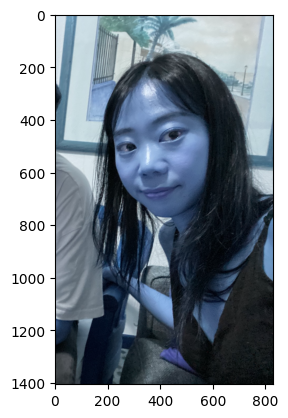

In [147]:
img_bgr = cv2.imread('IMG_7830.jpg')
plt.imshow(img_bgr)
plt.show()

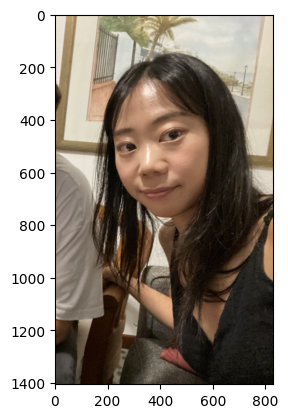

In [148]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

In [149]:
detector_hog = dlib.get_frontal_face_detector()
dlib_rects = detector_hog(img_rgb, 1)

In [150]:
print(dlib_rects)

rectangles[[(161, 333) (546, 718)]]


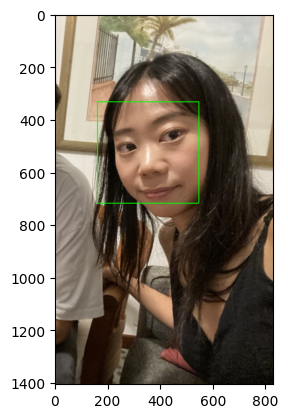

In [151]:
# 출력용 이미지
img_show = img_bgr.copy()

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [29]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d ./shape_predictor_68_face_landmarks.dat.bz2

--2025-01-24 02:24:08--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2.2’

shape_predictor_68_ 100%[===================>]  61.07M  48.0MB/s    in 1.3s    

2025-01-24 02:24:09 (48.0 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2.2’ saved [64040097/64040097]



In [30]:
model_path = 'shape_predictor_68_face_landmarks.dat'
landmark_predictor = dlib.shape_predictor(model_path)

In [152]:
list_landmarks = []

for dlib_rect in dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_rgb, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 랜드마크 리스트를 저장
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


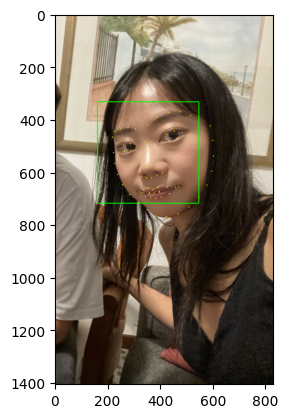

In [153]:
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

코 찾기

In [154]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    print (landmark[30])
    x = landmark[30][0]
    y = landmark[30][1] - dlib_rect.height()//2
    w = h = dlib_rect.width()
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(348, 580)
(x,y) : (348,387)
(w,h) : (386,386)


In [105]:
sticker_filename = 'cat-whiskers.png'
# img_sticker = cv2.imread(sticker_filename, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.imread(sticker_filename)
img_sticker = cv2.resize(img_sticker, (w,h))
print (img_sticker.shape)
# plt.imshow(cv2.cvtColor(img_sticker, cv2.COLOR_BGR2RGB))
# plt.show()

(386, 386, 3)


In [86]:
if img_sticker.shape[2] == 4:  # 채널이 4개인지 확인 (RGBA)
    alpha_channel = img_sticker[:, :, 3]
    print("알파 채널 값 (0은 완전 투명, 255는 완전 불투명):")
    print(alpha_channel)  # 알파 채널 값 출력

    # 알파 채널의 최소값, 최대값 확인
    print("알파 채널 최소값:", alpha_channel.min())
    print("알파 채널 최대값:", alpha_channel.max())
else:
    print("스티커 이미지에 알파 채널이 없음")

스티커 이미지에 알파 채널이 없음


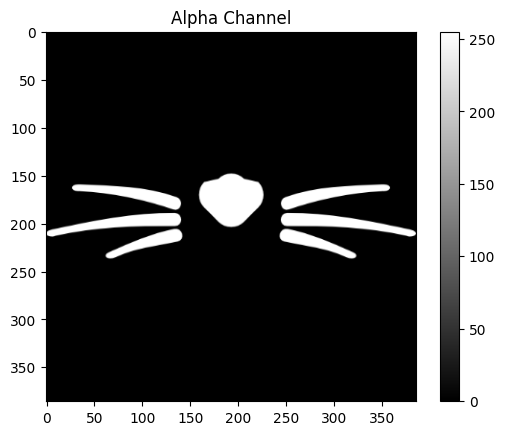

In [87]:
import matplotlib.pyplot as plt

# 알파 채널 시각화
plt.imshow(alpha_channel, cmap='gray')
plt.title("Alpha Channel")
plt.colorbar()
plt.show()

In [155]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 348
# y는 이미지에서 코 부위의 y값 = 387
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 386
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 386
refined_x = x - w // 2
refined_y = y
print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (155,387)


In [156]:
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0

# 스티커가 이미지 오른쪽으로 나갔을 때
if refined_x + img_sticker.shape[1] > img_show.shape[1]:
    excess_width = (refined_x + img_sticker.shape[1]) - img_show.shape[1]
    # 스티커의 오른쪽 부분을 잘라냄
    img_sticker = img_sticker[:, :-excess_width]

# 스티커가 이미지 아래쪽으로 나갔을 때
if refined_y + img_sticker.shape[0] > img_show.shape[0]:
    excess_height = (refined_y + img_sticker.shape[0]) - img_show.shape[0]
    # 스티커의 아래쪽 부분을 잘라냄
    img_sticker = img_sticker[:-excess_height, :]

print ('(x,y) : (%d,%d)'%(refined_x, refined_y))

(x,y) : (155,387)


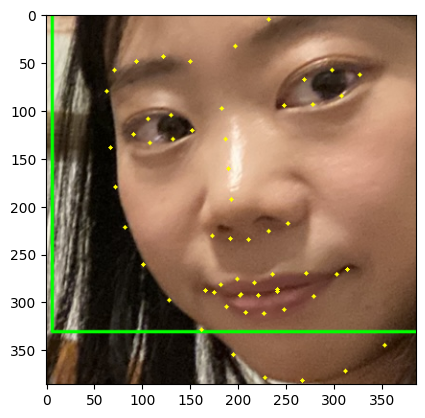

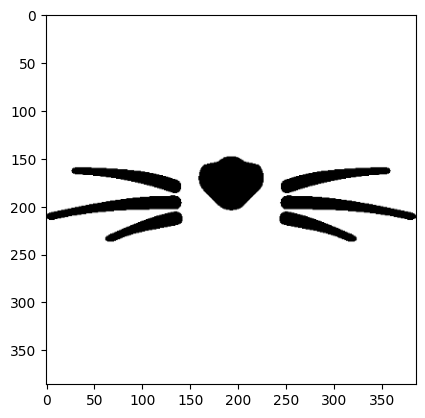

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


In [157]:
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
plt.imshow(cv2.cvtColor(sticker_area, cv2.COLOR_BGR2RGB))
plt.show()

# 고양이 수염 이미지에서는 0인 부분에 해당, 255는 배경
plt.imshow(cv2.cvtColor(img_sticker, cv2.COLOR_BGR2RGB))
plt.show()
print(img_sticker)

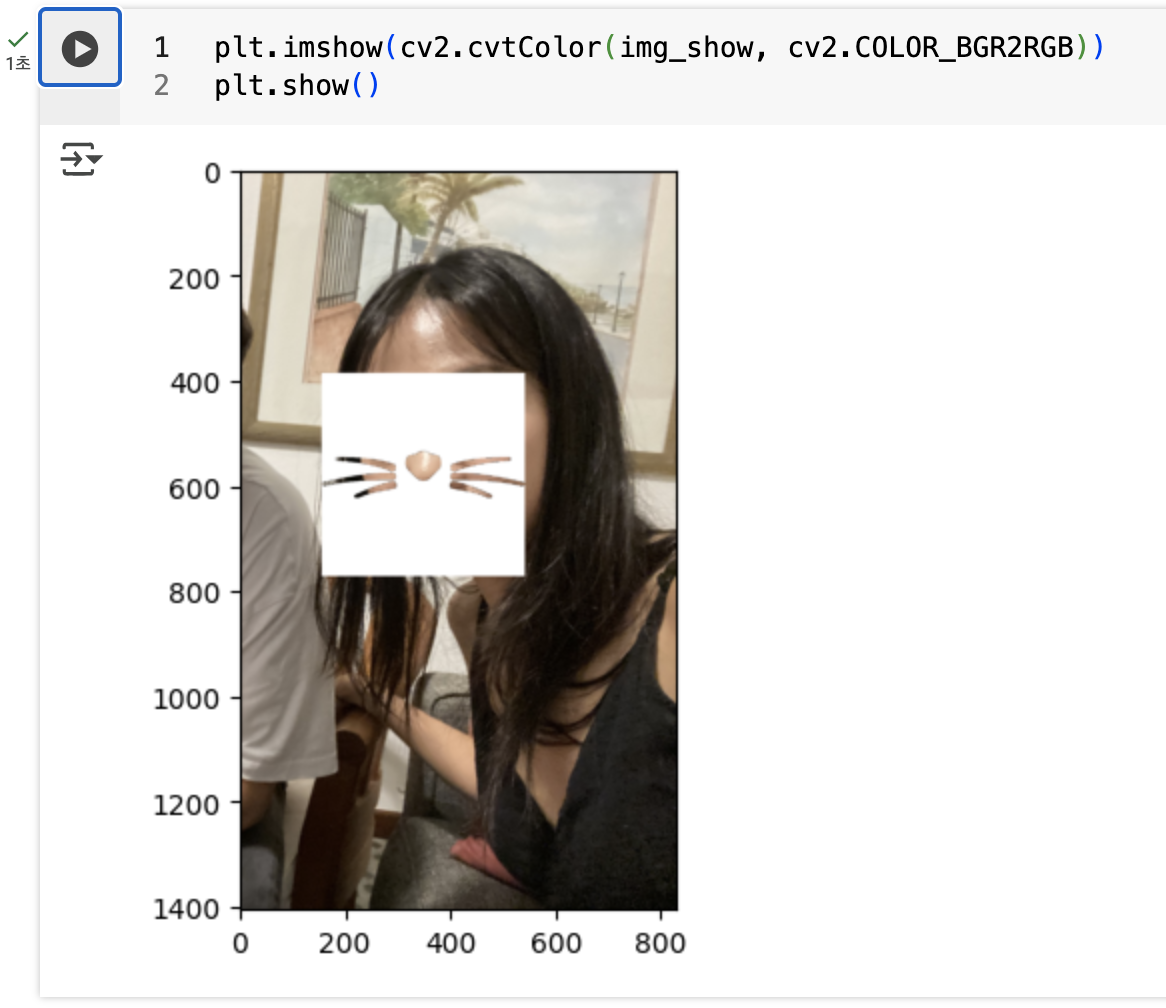

- 상황
  - 기존 코드를 사용했을 경우, 배경이 남고 수염이 사라짐
- 원인
  - 기존 코드는 img_sticker의 픽셀 값이 0이 아닐 때, 스티커를 적용해 줌.
  - 고양이 수염은 검은색이라 값이 0임
  - 따라서 반대로 적용됨
- 문제 해결
  - img_sticker 값이 0일 때, 스티커를 적용해 줌

In [158]:
# sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
#     np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)

# 고양이 수염 이미지에서는 0인 부분에 해당, 255는 배경 (예시랑 반대로 적용해줘야 함)
# 아래 코드에서는 img_sticker가 0일 경우에는 img_sticker(수염 이미지)를 적용하고,
# 나머지 부분은 sticker_area(원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지)를 적용
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,img_sticker,sticker_area).astype(np.uint8)

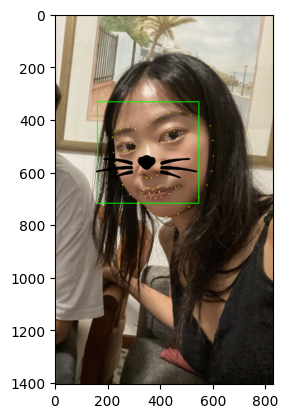

In [159]:
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

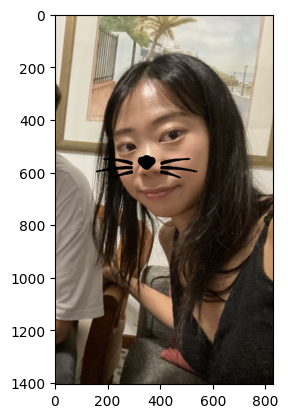

In [160]:
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,img_sticker,sticker_area).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

### 고양이 코를 얼굴에 맞게 살짝 회전해볼까?
![dlib_landmarks](https://ibug.doc.ic.ac.uk/media/uploads/images/annotpics/figure_68_markup.jpg)
- 37번 좌표랑 46번 좌표로 기울기를 구할 수 있지 않을까?
  - 0부터 인덱스 시작하니깐 36, 45번째 인덱스


In [170]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    print (landmark[36])
    left_x = landmark[36][0]
    left_y = landmark[36][1] - dlib_rect.height()//2
    print (f'left (x,y) : ({left_x},{left_y})')
    print (landmark[45])
    right_x = landmark[45][0]
    right_y = landmark[45][1] - dlib_rect.height()//2
    w = h = dlib_rect.width()
    print (f'right (x,y) : ({right_x},{right_y})')
    print (f'(w,h) : ({w},{h})')


(246, 512)
left (x,y) : (246,319)
(482, 450)
right (x,y) : (482,257)
(w,h) : (386,386)


In [175]:
from math import atan2, degrees
dx = right_x - left_x
dy = right_y - left_y
angle = degrees(atan2(dy, dx))

In [176]:
# 회전용 스티커 복사
rotated_img_sticker = img_sticker.copy()
(rotate_h, rotate_w) = rotated_img_sticker.shape[:2]  # 이미지 높이와 너비
# 중심 구하기
center = (rotate_w // 2, rotate_h // 2)
print(center)

(193, 193)


In [177]:
# 수염은 얼굴 각도랑 반대로 회전해줘야 하니깐 '-' 붙여줌
rotation_matrix = cv2.getRotationMatrix2D(center, -angle, 1.0)
print(rotation_matrix)

[[  0.96718062   0.25408983 -42.70519681]
 [ -0.25408983   0.96718062  55.37347569]]


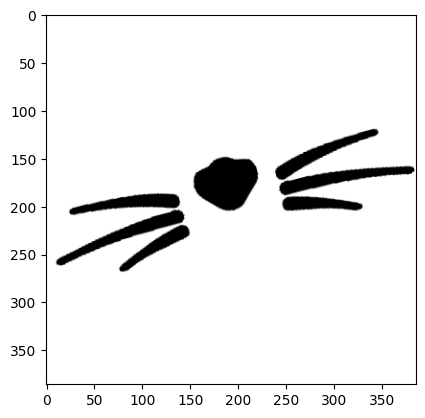

In [178]:
# 이미지 회전
rotated_img_sticker = cv2.warpAffine(rotated_img_sticker, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255, 0))
plt.imshow(cv2.cvtColor(rotated_img_sticker, cv2.COLOR_BGR2RGB))
plt.show()

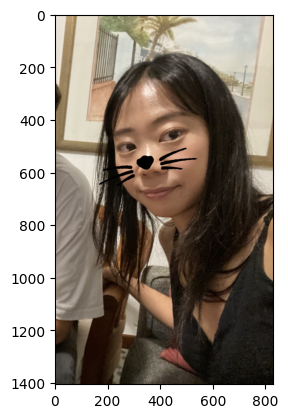

In [179]:
img_rotated = cv2.imread('IMG_7830.jpg')
sticker_area = img_rotated[refined_y:refined_y +rotated_img_sticker.shape[0], refined_x:refined_x+rotated_img_sticker.shape[1]]
img_rotated[refined_y:refined_y +rotated_img_sticker.shape[0], refined_x:refined_x+rotated_img_sticker.shape[1]] = \
    np.where(rotated_img_sticker==0,rotated_img_sticker,sticker_area).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_rotated, cv2.COLOR_BGR2RGB))
plt.show()

### 얼굴이 작을 때랑 누워있을 때는,.? 선글라스 썼을 때는?!

In [180]:
os.chdir('/content/gdrive/My Drive/Lecture/aiffel')
lying_bgr = cv2.imread('IMG_7617.jpg')
small_bgr = cv2.imread('IMG_9862.jpg')
sunglasses_bgr = cv2.imread('IMG_2071.jpg')

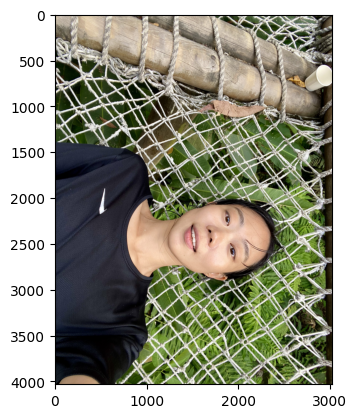

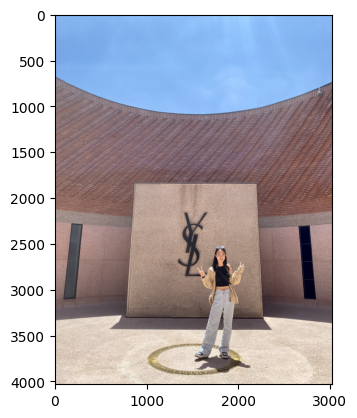

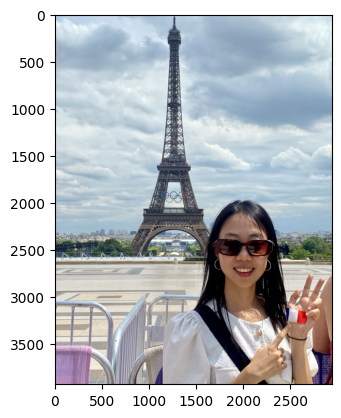

In [182]:
plt.imshow(cv2.cvtColor(lying_bgr, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(small_bgr, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(sunglasses_bgr, cv2.COLOR_BGR2RGB))
plt.show()

In [183]:
detector_hog = dlib.get_frontal_face_detector()
lying_dlib_rects = detector_hog(lying_bgr, 1)
small_dlib_rects = detector_hog(small_bgr, 1)
sunglasses_dlib_rects = detector_hog(sunglasses_bgr, 1)

print(lying_dlib_rects)
print(small_dlib_rects)
print(sunglasses_dlib_rects)

rectangles[]
rectangles[[(1752, 2600) (1859, 2708)]]
rectangles[[(1712, 2329) (2267, 2883)]]


누워있는 사진은 얼굴 인식을 못 했네

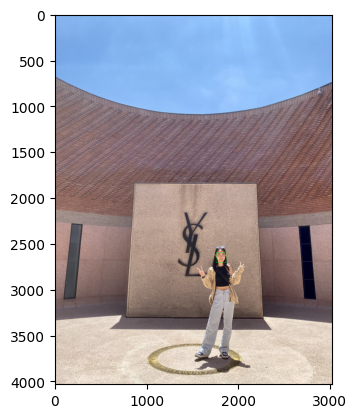

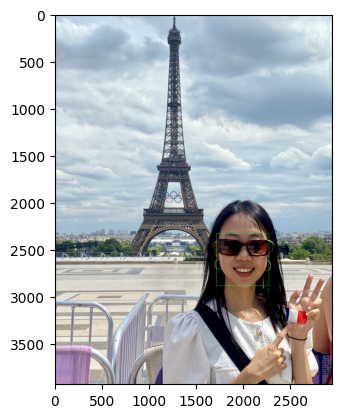

In [184]:
small_img_show = small_bgr.copy()
for dlib_rect in small_dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(small_img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

small_img_show_rgb =  cv2.cvtColor(small_img_show, cv2.COLOR_BGR2RGB)
plt.imshow(small_img_show_rgb)
plt.show()

sngls_img_show = sunglasses_bgr.copy()
for dlib_rect in sunglasses_dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(sngls_img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

sngls_img_show_rgb =  cv2.cvtColor(sngls_img_show, cv2.COLOR_BGR2RGB)
plt.imshow(sngls_img_show_rgb)
plt.show()

In [187]:
small_list_landmarks = []
for dlib_rect in small_dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(small_img_show_rgb, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 랜드마크 리스트를 저장
    small_list_landmarks.append(list_points)

print(len(small_list_landmarks[0]))
print(small_list_landmarks[0])

sngls_list_landmarks = []
for dlib_rect in sunglasses_dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(sngls_img_show_rgb, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 랜드마크 리스트를 저장
    sngls_list_landmarks.append(list_points)

print(len(sngls_list_landmarks[0]))
print(sngls_list_landmarks[0])

68
[(1754, 2626), (1756, 2641), (1760, 2656), (1763, 2669), (1769, 2681), (1778, 2691), (1789, 2699), (1800, 2705), (1811, 2707), (1821, 2704), (1829, 2696), (1836, 2687), (1843, 2677), (1847, 2665), (1849, 2652), (1850, 2638), (1850, 2623), (1765, 2616), (1771, 2609), (1781, 2606), (1790, 2607), (1799, 2611), (1815, 2610), (1823, 2607), (1832, 2606), (1840, 2609), (1844, 2616), (1808, 2624), (1809, 2633), (1810, 2643), (1811, 2652), (1799, 2658), (1805, 2659), (1810, 2660), (1815, 2659), (1819, 2657), (1777, 2626), (1782, 2623), (1788, 2623), (1794, 2627), (1788, 2628), (1782, 2627), (1819, 2628), (1825, 2623), (1830, 2623), (1836, 2625), (1831, 2627), (1825, 2628), (1788, 2672), (1797, 2668), (1805, 2667), (1811, 2668), (1816, 2667), (1823, 2668), (1829, 2670), (1823, 2681), (1817, 2685), (1811, 2686), (1805, 2685), (1797, 2682), (1790, 2672), (1805, 2671), (1811, 2672), (1816, 2671), (1827, 2670), (1816, 2679), (1810, 2680), (1805, 2679)]
68
[(1740, 2486), (1742, 2553), (1744, 2619)

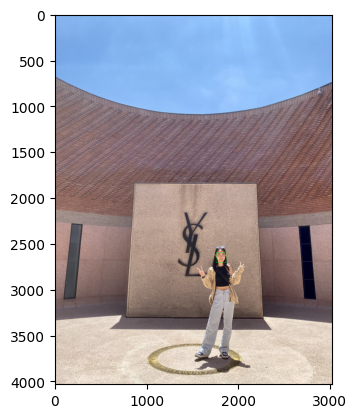

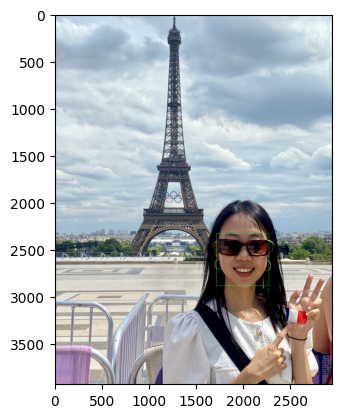

In [186]:
for landmark in small_list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

small_img_show_rgb = cv2.cvtColor(small_img_show, cv2.COLOR_BGR2RGB)
plt.imshow(small_img_show_rgb)
plt.show()

for landmark in sngls_list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

sngls_img_show_rgb = cv2.cvtColor(sngls_img_show, cv2.COLOR_BGR2RGB)
plt.imshow(sngls_img_show_rgb)
plt.show()

In [189]:
for dlib_rect, landmark in zip(small_dlib_rects, small_list_landmarks):
    print (landmark[30])
    small_x = landmark[30][0]
    small_y = landmark[30][1] - dlib_rect.height()//2
    small_w = small_h = dlib_rect.width()
    print (f'small (x,y) : ({small_x},{small_y})')
    print (f'small (w,h) : ({small_w},{small_h})')

for dlib_rect, landmark in zip(sunglasses_dlib_rects, sngls_list_landmarks):
    print (landmark[30])
    sngls_x = landmark[30][0]
    sngls_y = landmark[30][1] - dlib_rect.height()//2
    sngls_w = sngls_h = dlib_rect.width()
    print (f'sunglasses (x,y) : ({sngls_x},{sngls_y})')
    print (f'sunglasses (w,h) : ({sngls_w},{sngls_h})')

(1811, 2652)
small (x,y) : (1811,2598)
small (w,h) : (108,108)
(2008, 2598)
sunglasses (x,y) : (2008,2321)
sunglasses (w,h) : (556,556)


In [190]:
sticker_filename = 'cat-whiskers.png'
img_sticker = cv2.imread(sticker_filename)
small_img_sticker = cv2.resize(img_sticker, (small_w,small_h))
sngls_img_sticker = cv2.resize(img_sticker, (sngls_w,sngls_h))

In [191]:
small_x = small_x - small_w // 2
small_y = small_y
print (f'small (x,y) : ({small_x},{small_y})')

sngls_x = sngls_x - sngls_w // 2
sngls_y = sngls_y
print (f'sunglasses (x,y) : ({sngls_x},{sngls_y})')

small (x,y) : (1757,2598)
sunglasses (x,y) : (1730,2321)


In [192]:
if small_x < 0:
    small_img_sticker = small_img_sticker[:, -small_x:]
    small_x = 0
if small_y < 0:
    small_img_sticker = small_img_sticker[-small_y:, :]
    small_y = 0

print ('(x,y) : (%d,%d)'%(small_x, small_y))

if sngls_x < 0:
    sngls_img_sticker = sngls_img_sticker[:, -sngls_x:]
    sngls_x = 0
if sngls_y < 0:
    sngls_img_sticker = sngls_img_sticker[-sngls_y:, :]
    sngls_y = 0

print ('(x,y) : (%d,%d)'%(sngls_x, sngls_y))

(x,y) : (1757,2598)
(x,y) : (1730,2321)


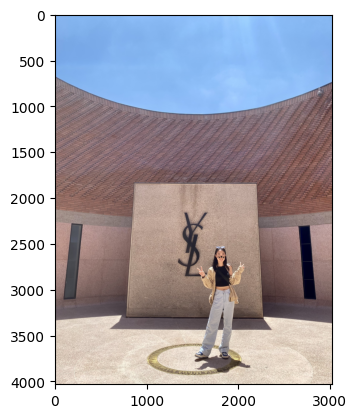

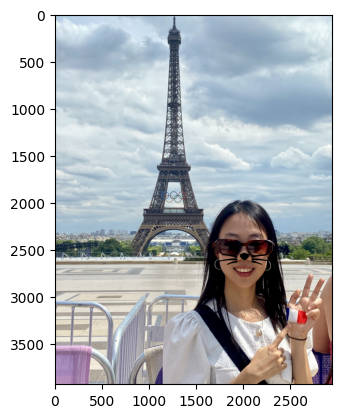

In [195]:
small_sticker_area = small_bgr[small_y:small_y +small_img_sticker.shape[0], small_x:small_x+small_img_sticker.shape[1]]
small_bgr[small_y:small_y +small_img_sticker.shape[0], small_x:small_x+small_img_sticker.shape[1]] = \
    np.where(small_img_sticker==0,small_img_sticker,small_sticker_area).astype(np.uint8)
plt.imshow(cv2.cvtColor(small_bgr, cv2.COLOR_BGR2RGB))
plt.show()

sngls_sticker_area = sunglasses_bgr[sngls_y:sngls_y +sngls_img_sticker.shape[0], sngls_x:sngls_x+sngls_img_sticker.shape[1]]
sunglasses_bgr[sngls_y:sngls_y +sngls_img_sticker.shape[0], sngls_x:sngls_x+sngls_img_sticker.shape[1]] = \
    np.where(sngls_img_sticker==0,sngls_img_sticker,sngls_sticker_area).astype(np.uint8)
plt.imshow(cv2.cvtColor(sunglasses_bgr, cv2.COLOR_BGR2RGB))
plt.show()

- 얼굴이 작은건 레졸루션이 좋아서 인식이 잘 된 듯
- 모델이 선글라스 낀 얼굴도 학습하는 듯

### 너무 귀찮네.. 함수화하자
- Pseudo code
```
def apply_cat_sticker(image, sticker):
  # 1. 이미지에서 얼굴 추출
  faces = get_faces(image)
  # 2. 랜드마크 추출
  landmarks = get_landmarks(faces)
  # 3. 코 좌표 찾기
  noses = calculate_noses(landmarks)
  # 4. 각도 계산
  angles = calculate_angles(landmarks)
  # 5. 스티커 붙이기
  attached_image = attach_cat_sticker(image, sticker, angles)
  return attached_image
```

In [258]:
"""Detect the human faces using dlib face detector

Parameters
----------
image : rgb image - if using opencv, you might need to convert to rgb

Raises
------
Exception : if no face is detected, raise an exception
"""
def get_faces(image):
  detector_hog = dlib.get_frontal_face_detector()
  dlib_rects = detector_hog(image, 1)
  if len(dlib_rects) < 1:
    raise Exception(f'Cannot find the face.')

  return dlib_rects

In [260]:
"""Detect the face landmarks using dlib shape predictor

Parameters
----------
image      : rgb image - if using opencv, you might need to convert to rgb
dlib_rects : face bounding boxes from get_faces() method

Raises
------
Exception : if model cannot predict landmarks, raise an exception
Exception : each landmark using shape predictor always has 68 of face landmarks
"""
def get_landmarks(image, dlib_rects):
  landmark_predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')
  list_landmarks = []

  for dlib_rect in dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(image, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 랜드마크 리스트를 저장
    list_landmarks.append(list_points)

  if len(list_landmarks) < 1:
    raise Exception(f'Cannot find the landmarks.')

  if len(list_landmarks[0]) != 68:
    raise Exception(f'Invalid landmarks.')

  return list_landmarks

In [295]:
"""Calculate each nose points of the faces

Parameters
----------
dlib_rects : face bounding boxes from get_faces() method
landmarks  : face landmarks from get_landmarks() method
"""
NUM_NOSE = 30
def calculate_noses(dlib_rects, list_landmarks):
  noses = []
  for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    nose = {}
    nose['x'] = landmark[30][0]
    nose['y'] = landmark[30][1] - dlib_rect.height()//2
    nose['w'] = nose['h'] = dlib_rect.width()
    noses.append(nose)

  return noses

In [300]:
"""Calculate each angle of the faces

Parameters
----------
dlib_rects : face bounding boxes from get_faces() method
landmarks  : face landmarks from get_landmarks() method
"""
from math import atan2, degrees

NUM_LEFT_EYE = 36
NUM_RIGHT_EYE = 45
def calculate_angles(dlib_rects, list_landmarks):
  angles = []

  for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    l_eye_x = landmark[NUM_LEFT_EYE][0]
    l_eye_y = landmark[NUM_LEFT_EYE][1] - dlib_rect.height()//2

    r_eye_x = landmark[NUM_RIGHT_EYE][0]
    r_eye_y = landmark[NUM_RIGHT_EYE][1] - dlib_rect.height()//2
    w = h = dlib_rect.width()

    dx = r_eye_x - l_eye_x
    dy = r_eye_y - l_eye_y
    angle = degrees(atan2(dy, dx))
    angles.append(angle)

  return angles

In [252]:
"""Return RGB list of the input color

Parameters
----------
color : string value
"""
def get_color_code(color):
  rgb = [0, 0, 0]
  if color == 'red':
    rgb = [0, 0, 255]
  elif color == 'green':
    rgb = [0, 255, 0]
  elif color == 'blue':
    rgb = [255, 0, 0]
  elif color == 'pink':
    rgb = [207, 198, 251]
  else:
    rgb = [0, 0, 0]
  return rgb

In [301]:
def attach_stickers(image, sticker, noses, angles, color='none'):
  if len(noses) != len(angles):
    raise Exception(f'Invalid paramters, noses len: {len(noses)}, angles len: {len(angles)}')

  num_of_faces = len(noses)
  image_show = image.copy()

  for i in range(num_of_faces):
    ### sticker resize ###
    nose = noses[i]
    image_sticker = cv2.resize(sticker, (nose['w'],nose['h']))
    # target location
    x = nose['x'] - nose['w'] // 2
    y = nose['y']

    ### sticker rotate ###
    angle = angles[i]
    # 스티커의 높이와 너비
    (rotate_h, rotate_w) = image_sticker.shape[:2]
    center = (rotate_w // 2, rotate_h // 2)
    # 수염은 얼굴 각도랑 반대로 회전해줘야 하니깐 '-' 붙여줌
    rotation_matrix = cv2.getRotationMatrix2D(center, -angle, 1.0)
    image_sticker = cv2.warpAffine(image_sticker, rotation_matrix,(nose['w'], nose['h']),
                                   flags=cv2.INTER_LINEAR,
                                   borderMode=cv2.BORDER_CONSTANT,
                                   borderValue=(255, 255, 255, 0))

    ### sticker omit ###
    # 이미지가 왼쪽이랑 위쪽으로 나갔을 때
    if x < 0:
      image_sticker = image_sticker[:, -x:]
      x = 0
    if y < 0:
      image_sticker = image_sticker[-y:, :]
      y = 0

    # 이미지가 오른쪽이랑 아래쪽으로 나갔을 때
    if x + image_sticker.shape[1] > image_show.shape[1]:
      excess_width = (x + image_sticker.shape[1]) - image_show.shape[1]
      image_sticker = image_sticker[:, :-excess_width]

    if y + image_sticker.shape[0] > image_show.shape[0]:
      excess_height = (y + image_sticker.shape[0]) - image_show.shape[0]
      image_sticker = image_sticker[:-excess_height, :]

    ### 이미지에 스티커 삽입 ###
    # rgb 색깔
    sticker_color = get_color_code(color)
    # apply
    sticker_area = image_show[y:y+image_sticker.shape[0], x:x+image_sticker.shape[1]]
    image_show[y:y +image_sticker.shape[0], x:x+image_sticker.shape[1]] = \
      np.where(image_sticker==0,sticker_color,sticker_area).astype(np.uint8)

  return image_show


In [302]:
def apply_cat_sticker(image, sticker, color='none'):
  # 1. 이미지에서 얼굴 추출
  faces = get_faces(image)
  # 2. 랜드마크 추출
  landmarks = get_landmarks(image, faces)
  # 3. 코 좌표 찾기
  noses = calculate_noses(faces, landmarks)
  # 4. 각도 계산
  angles = calculate_angles(faces, landmarks)
  # 5. 스티커 붙이기
  attached_image = attach_stickers(image, sticker, noses, angles, color)
  return attached_image

In [303]:
# 함수 테스트
test_image = cv2.imread('IMG_7830.jpg')
test_sticker = cv2.imread('cat-whiskers.png')

image_with_sticker = apply_cat_sticker(test_image, test_sticker, 'pink')

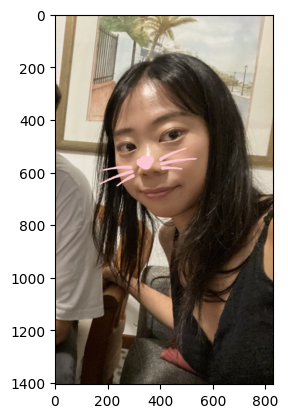

In [299]:
plt.imshow(cv2.cvtColor(image_with_sticker, cv2.COLOR_BGR2RGB))
plt.show()

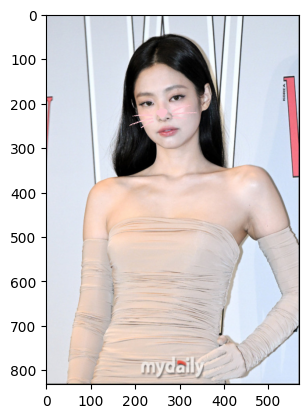

In [304]:
test_one = cv2.imread('jenny.jpeg')
one_sticker = apply_cat_sticker(test_one, test_sticker, 'pink')
plt.imshow(cv2.cvtColor(one_sticker, cv2.COLOR_BGR2RGB))
plt.show()

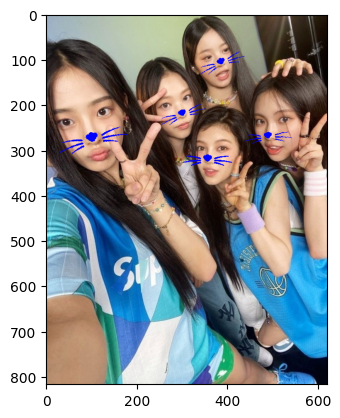

In [306]:
# 여러명 테스트
test_multi = cv2.imread('test_multipeople.jpeg')
test_multi_sticker = apply_cat_sticker(test_multi, test_sticker, 'blue')
plt.imshow(cv2.cvtColor(test_multi_sticker, cv2.COLOR_BGR2RGB))
plt.show()

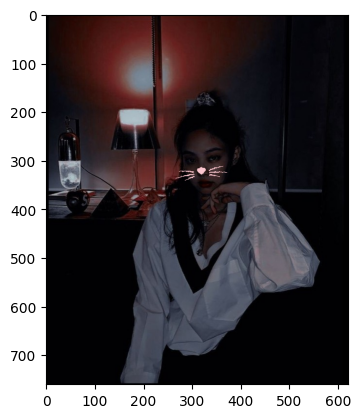

In [308]:
test_one = cv2.imread('dark_jenny.jpeg')
one_sticker = apply_cat_sticker(test_one, test_sticker, 'pink')
plt.imshow(cv2.cvtColor(one_sticker, cv2.COLOR_BGR2RGB))
plt.show()